In [34]:
import numpy as np 
import pennylane as qml
import matplotlib.pyplot as plt

from time import time
from scipy.linalg import dft
from functools import partial
import jax

ModuleNotFoundError: No module named 'jax'

# Quantum Fourier Transform

In [2]:
N = 16

def f(x):
    x = x % N
    return 0.5 * (x - 4) ** 3

In [3]:
def f_hat(k):
    projection = [f(x) * np.exp(2 * 1.j * k * x * np.pi / N) for x in range(N)]
    return 1 / np.sqrt(N) * np.sum(projection)

In [4]:
integers = np.array(range(N))
f_vec = np.array([f(x) for x in integers])
f_hat_vec = np.array([f_hat(x) for x in integers])

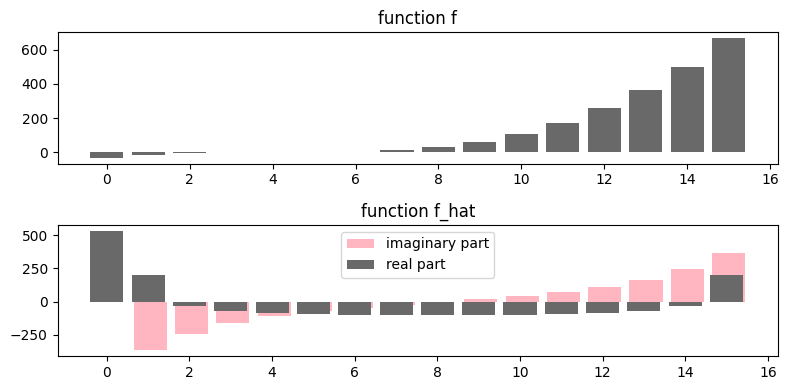

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4))
ax1.bar(integers, np.real(f_vec), color="dimgray")
ax1.set_title(f"function f")
ax2.bar(integers + 0.05, np.imag(f_hat_vec), color="lightpink", label="imaginary part")
ax2.bar(integers, np.real(f_hat_vec), color="dimgray", label="real part")
ax2.set_title(f"function f_hat")
plt.legend()
plt.tight_layout()
plt.show()

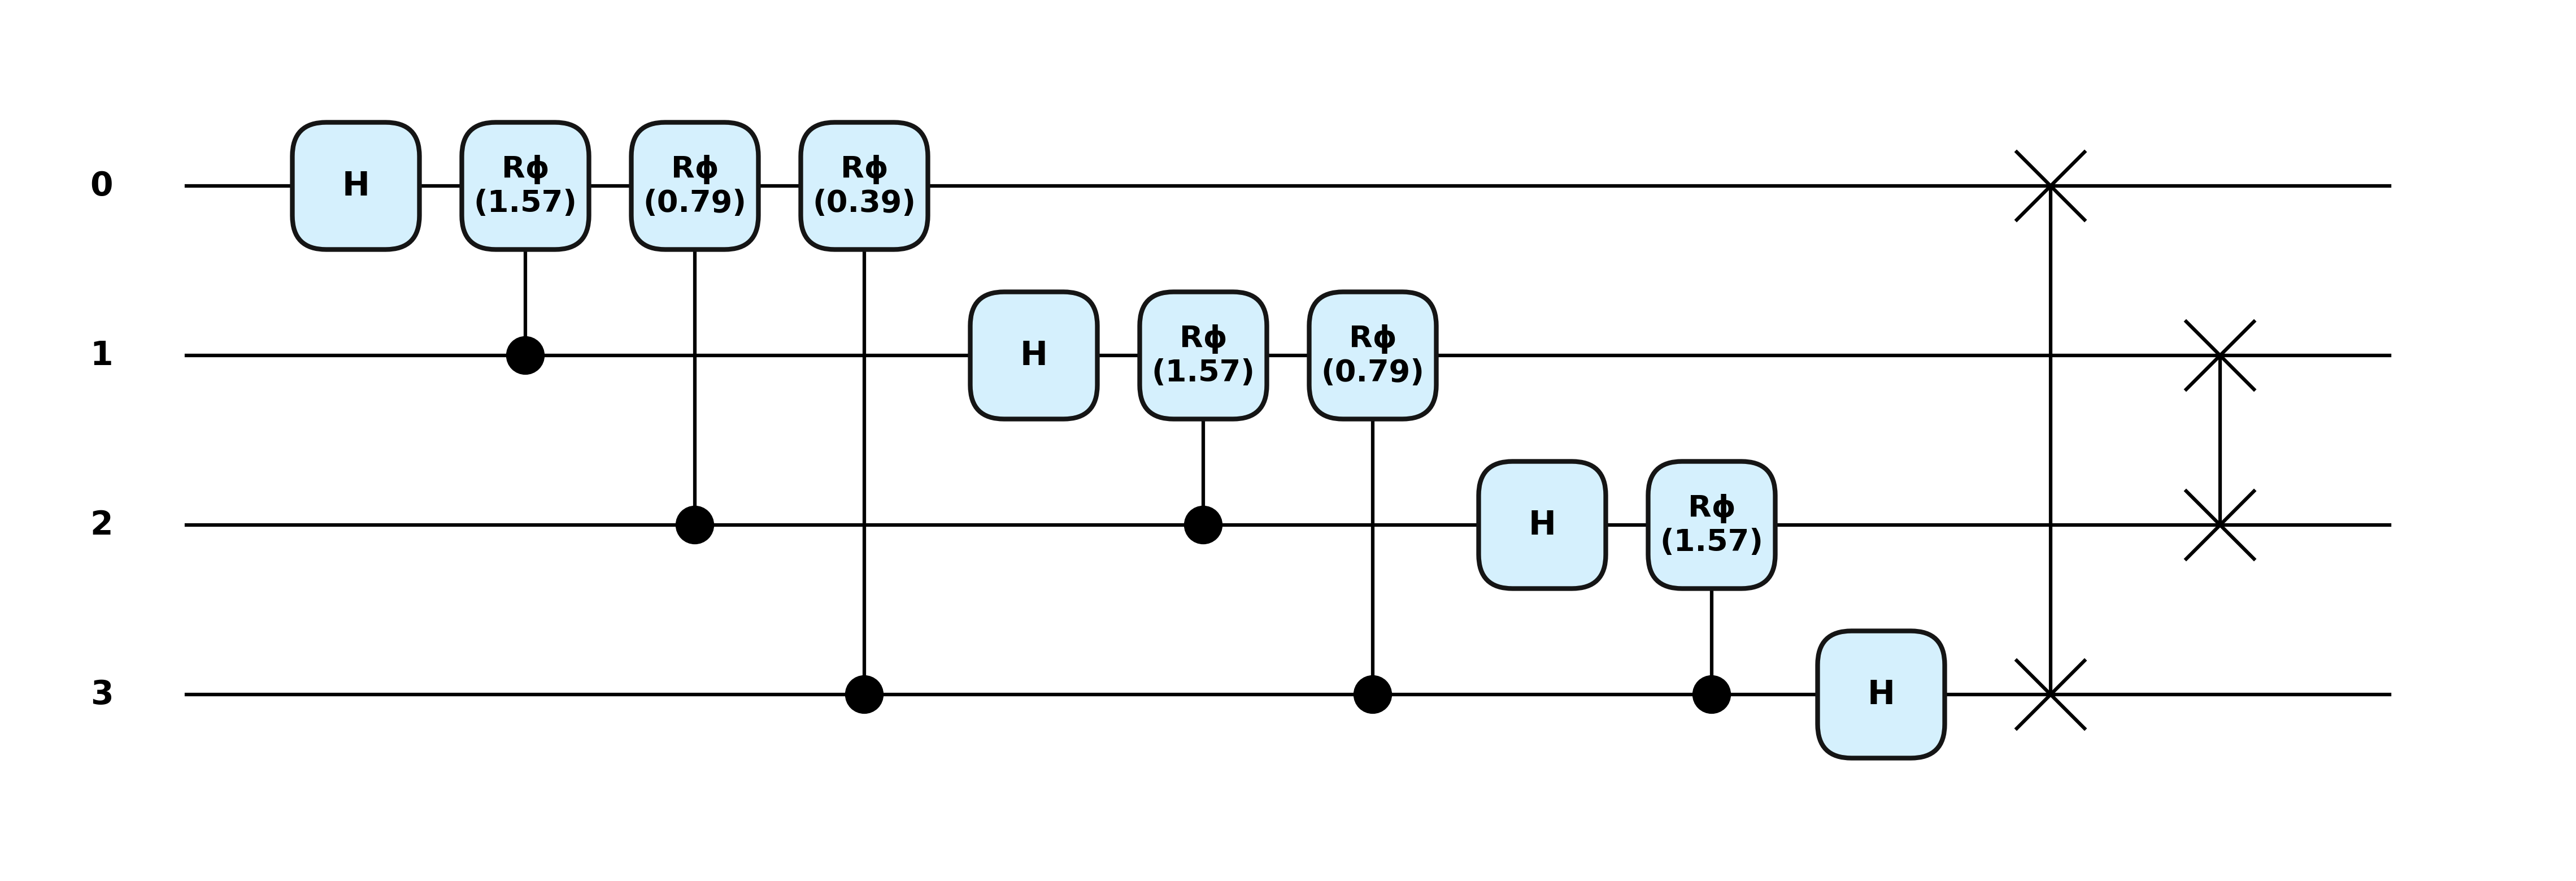

In [6]:
plt.style.use("pennylane.drawer.plot")

@partial(qml.transforms.decompose, max_expansion=1)
def circuit():
    qml.QFT(wires=range(4))

qml.draw_mpl(circuit, decimals=2, style="pennylane")()
plt.show()

In [7]:
import pennylane as qml
import numpy as np

def qft_state(n):
    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev)
    def circuit():
        for j in range(n):
            qml.Hadamard(wires=j)
            for k in range(2, n - j + 1):
                control = j + k - 1
                angle = 2 * np.pi / (2 ** k)   # k=2 -> π/2, k=3 -> π/4, ...
                qml.CPhase(angle, wires=[control, j])
        for i in range(n // 2):
            qml.SWAP(wires=[i, n - 1 - i])
        return qml.probs()

    return circuit()

In [8]:
state = qft_state(16)[:32]

<BarContainer object of 32 artists>

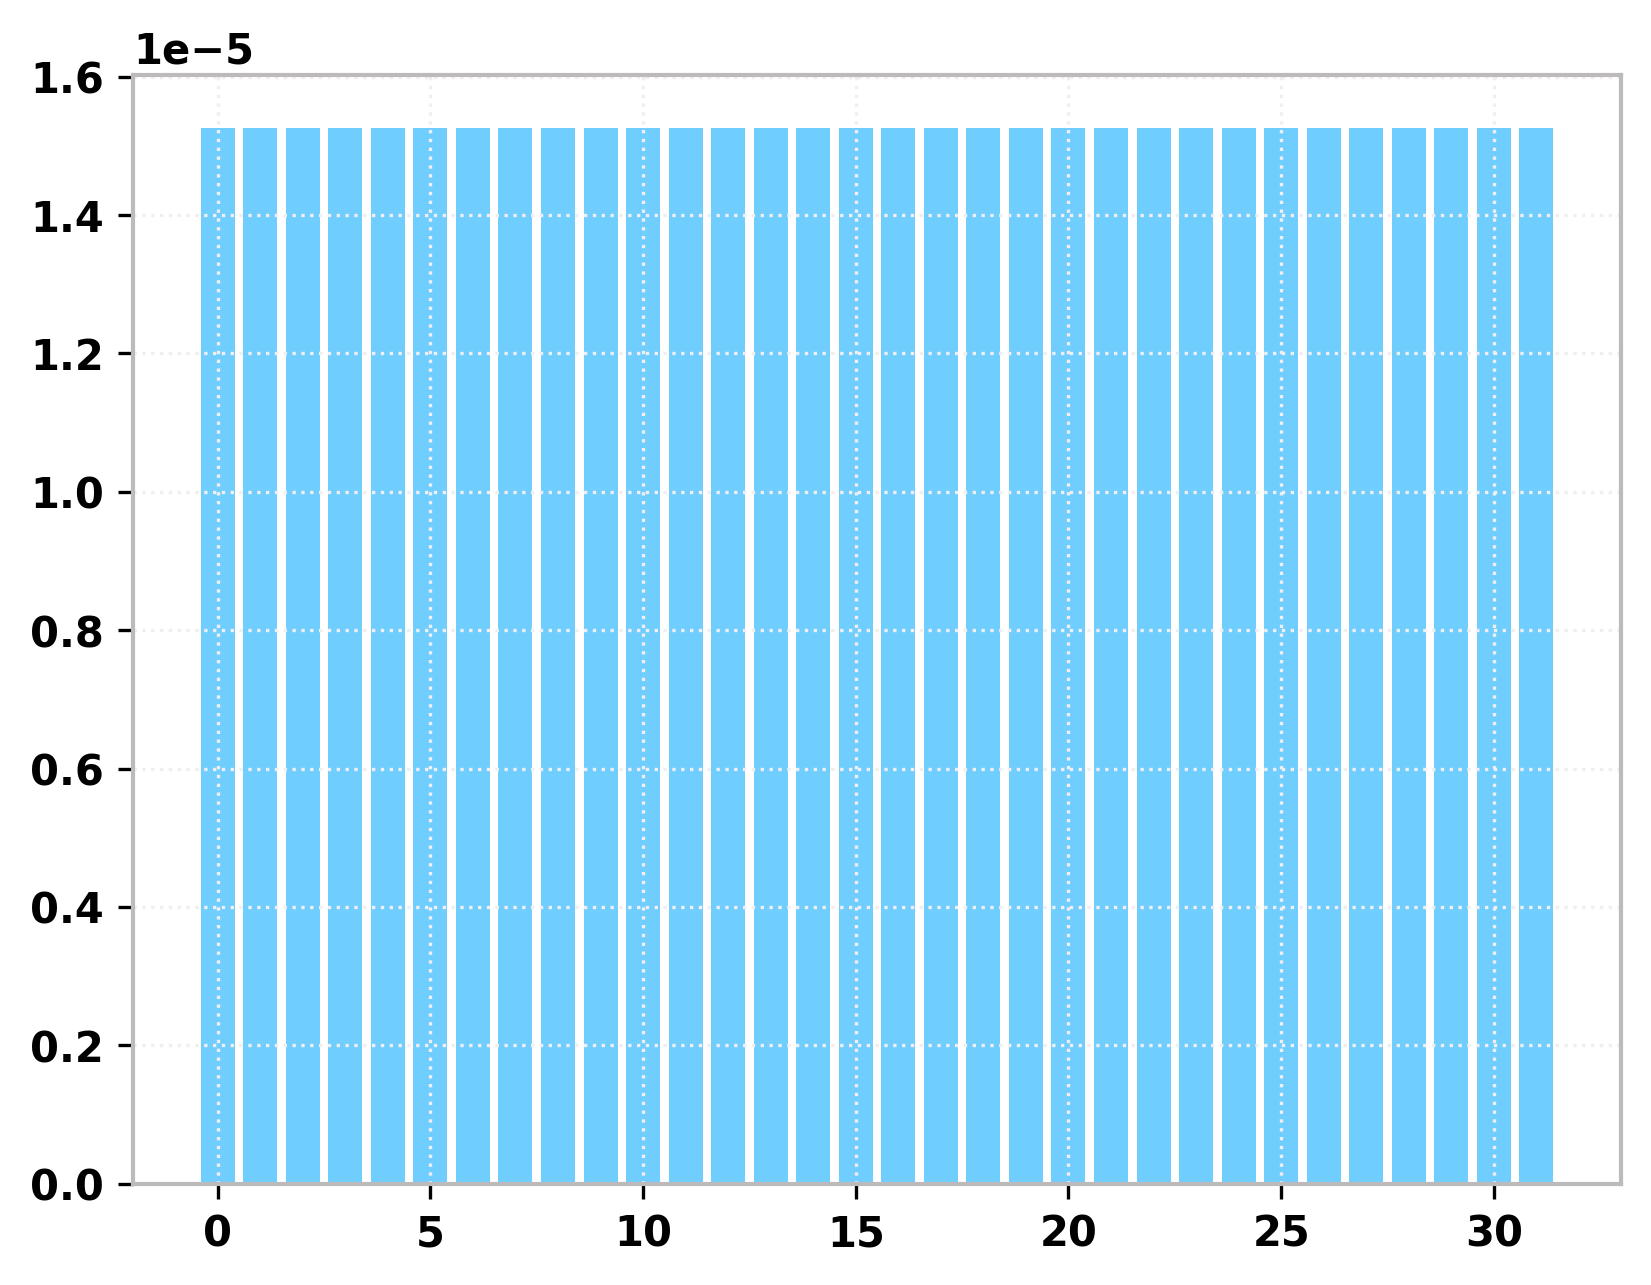

In [9]:
plt.bar(range(len(state)), state)

# Quantum Phase Estimation

In [11]:
def U(wires):
    return qml.PhaseShift(2 * np.pi / 5, wires=wires)

In [30]:
dev = qml.device("default.qubit")

@qml.qnode(dev)
def circuit_qpe(estimation_wires):
    # initialize to state |1>
    qml.PauliX(wires=0)

    for wire in estimation_wires:
        qml.Hadamard(wires=wire)

    qml.ControlledSequence(U(wires=0), control=estimation_wires)

    qml.adjoint(qml.QFT)(wires=estimation_wires)

    return qml.probs(wires=estimation_wires)

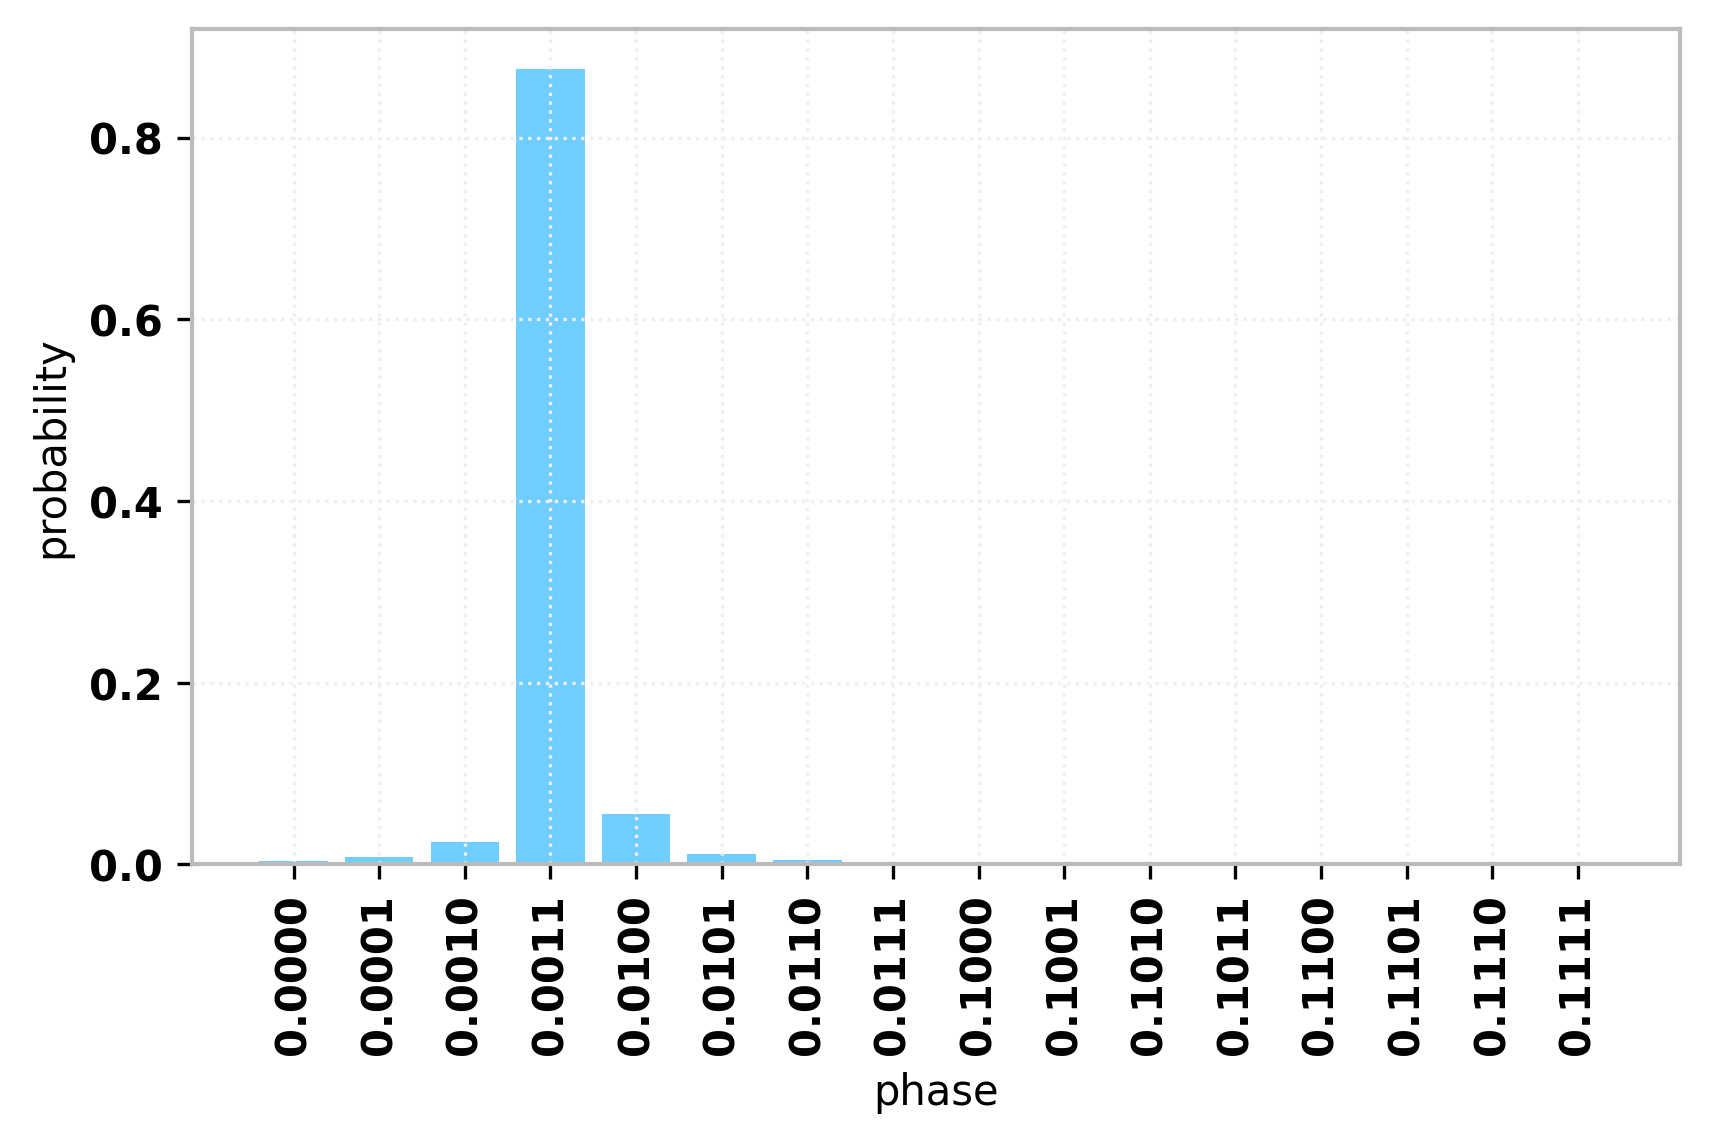

In [31]:
import matplotlib.pyplot as plt

estimation_wires = range(1, 5)

results = circuit_qpe(estimation_wires)

bit_strings = [f"0.{x:0{len(estimation_wires)}b}" for x in range(len(results))]

plt.bar(bit_strings, results)
plt.xlabel("phase")
plt.ylabel("probability")
plt.xticks(rotation="vertical")
plt.subplots_adjust(bottom=0.3)

plt.show()

In [25]:
def qpe_state(n: int, device_name: str):

    device = qml.device(device_name, wires=n + 1)
    
    @qml.qnode(device)
    def circuit(state=None):
        if not state:
            qml.PauliX(wires=0)
        for wire in range(1, n):
            qml.Hadamard(wires=wire)
        qml.ControlledSequence(U(wires=0), control=range(1, n))
        qml.QFT(wires=range(1, n))
        return qml.probs(wires=range(1, n))
    
    return circuit()

In [26]:
state = qpe_state(4, "default.qubit")

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (4,) and arg 1 with shape (8,).

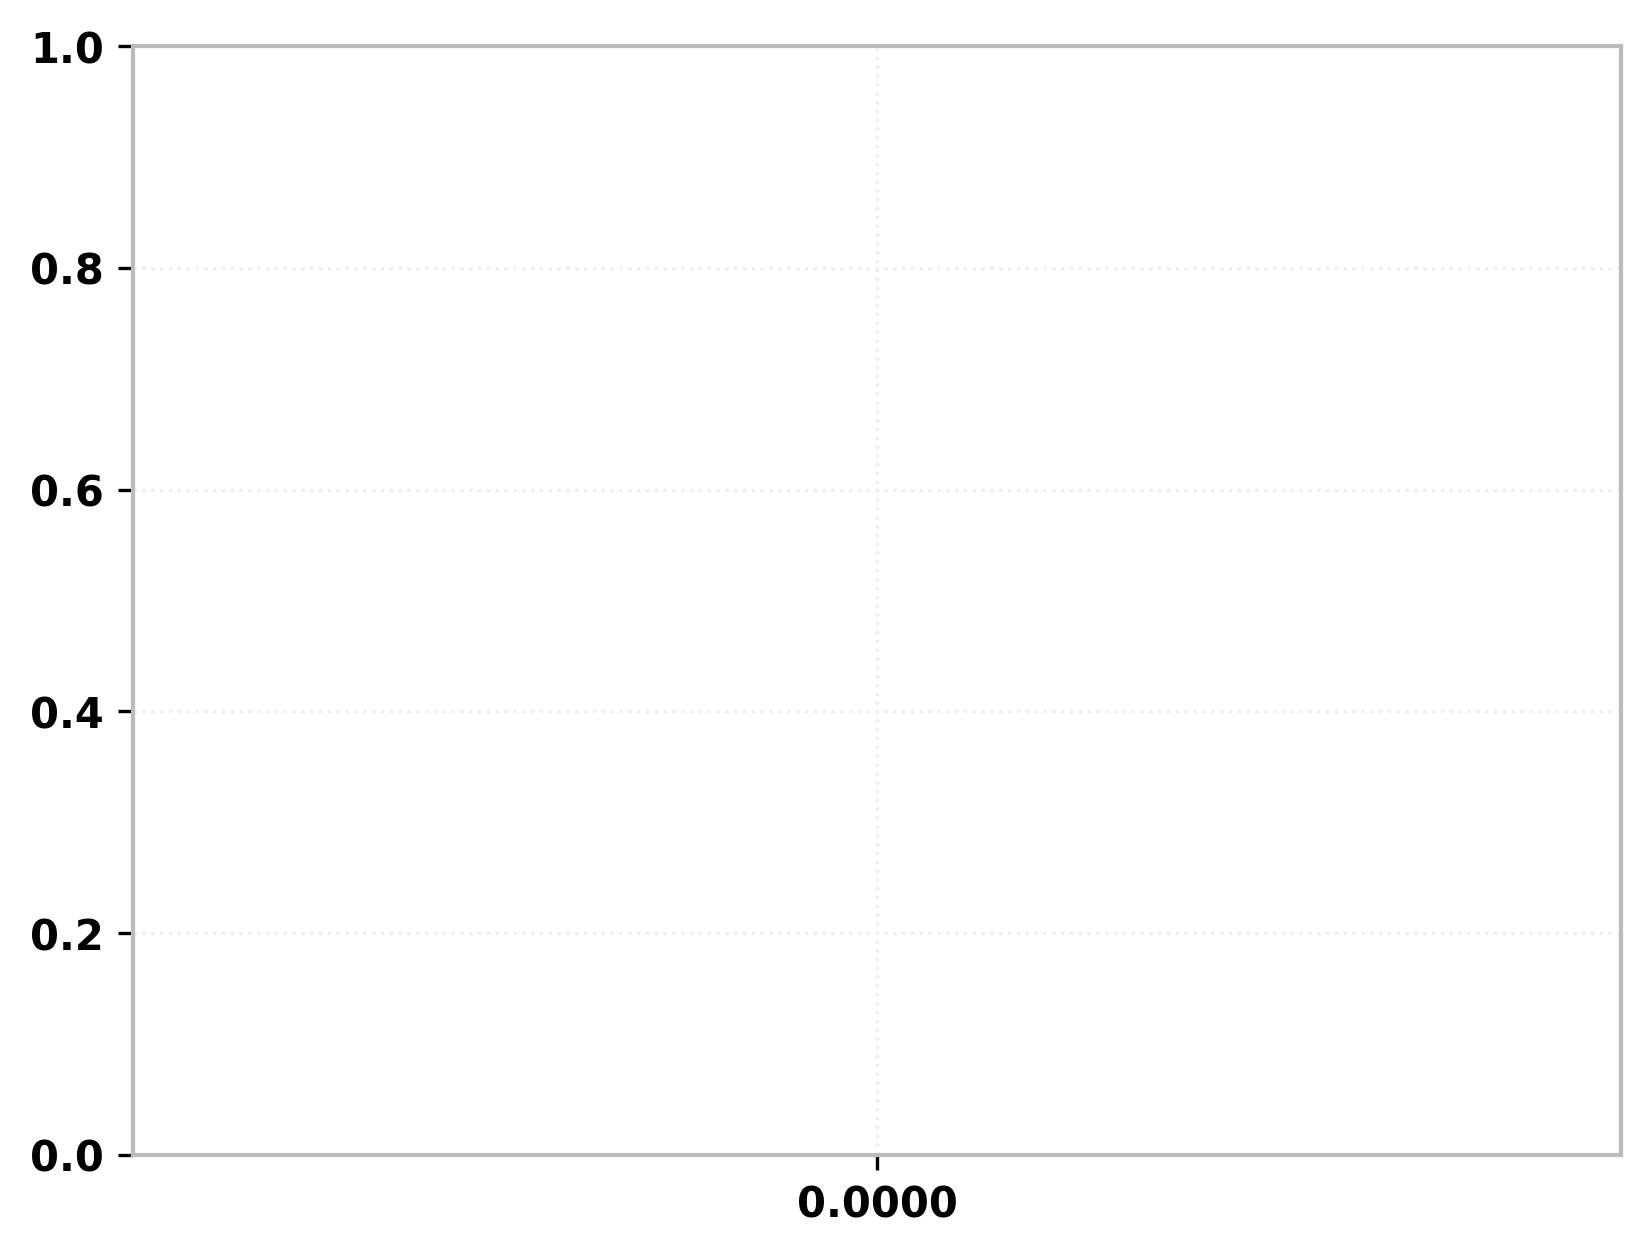

In [32]:
bit_strings = [f"0.{x:0{4}b}" for x in range(4)]
plt.bar(bit_strings, state)
plt.xlabel("Phase")
plt.ylabel("Probablility")
plt.xticks(rotation="vertical")
plt.subplots_adjust(bottom=0.3)
plt.show()

# Period finding

In [69]:
def f(x):
    return x % 8

In [70]:
def to_int(binary: str):
    return int(binary, 2)

def to_binary(integer: int, n):
    return format(integer, 'b').zfill(n)

In [97]:
def Oracle(f):
    U = np.zeros((2 ** 7, 2 ** 7))
    for x in range(2 ** 4):
        for f_x in range(2 ** 3):
            if f_x == 0:
                i = to_int(to_binary(x, 4) + '0' * 3)
                j = to_int(to_binary(x, 4) + to_binary(f(x), 3))
                U[i, j] = 1
                U[j, i] = 1
            else:
                i = to_int(to_binary(x, 4) + to_binary(f_x, 3))
                U[i, i] = 1
    assert np.allclose(U @ np.linalg.inv(U), np.eye(2 ** 7))
    return qml.QubitUnitary(U, wires=range(7))

In [100]:
dev = qml.device("default.qubit", wires=7)

@qml.set_shots(2)
@qml.qnode(dev)
def circuit():
    for i in range(4):
        qml.Hadamard(i)
    qml.Snapshot("initial_state")
    Oracle(f)
    qml.Snapshot("loaded_function")
    qml.QFT(wires=range(4))
    qml.Snapshot("fourier_spectrum")
    return qml.sample(wires=range(4))

samples = circuit()

In [101]:
from fractions import Fraction
from math import lcm

sampl1_int = to_int("".join((str(s) for s in samples[0])))
sampl2_int = to_int("".join((str(s) for s in samples[1])))

denominator1 = Fraction(sampl1_int / (2 ** 4)).denominator
denominator2 = Fraction(sampl2_int / (2 ** 4)).denominator

result = lcm(denominator1, denominator2)

print(f"Hidden period: {result}")

Hidden period: 8
